### Chapter 2 Coverage
This chapter covers:
- Exploring the dataset
- Creating a custom dataset
- Splitting the dataset
- Transforming the data
- Creating dataloaders
- Building the classification model
- Defining the loss function
- Defining the optimizer
- Training and evaluation of the model
- Deploying the model
- Model inference on test data

### Exploring the Dataset

In [1]:
import pandas as pd
import matplotlib.pylab as plt
from PIL import Image, ImageDraw
import numpy as np
import os
%matplotlib inline

In [2]:
path2csv = './data/train_labels.csv'

df_labels = pd.read_csv(path2csv)
df_labels.head()

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [3]:
print(df_labels['label'].value_counts())

label
0    130908
1     89117
Name: count, dtype: int64


In [4]:
df_labels.hist()

array([[<Axes: title={'center': 'label'}>]], dtype=object)

In [5]:
malignantIDs = df_labels.loc[df_labels['label']==1]['id'].values

In [6]:
path2train = './data/train'
color = False

In [7]:
# Define figure sizes
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
nrows,ncols = 3,3

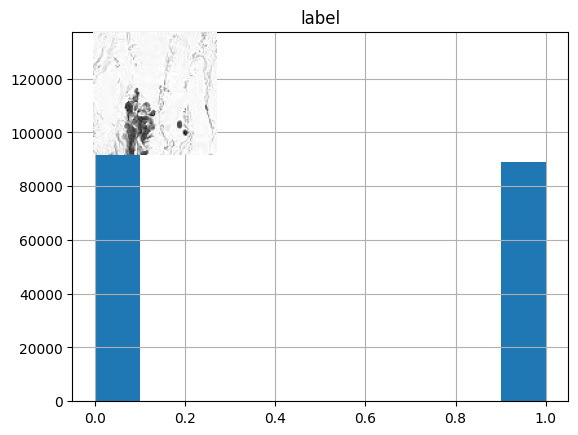

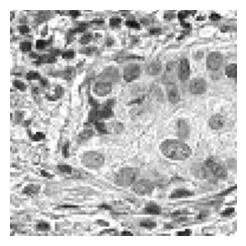

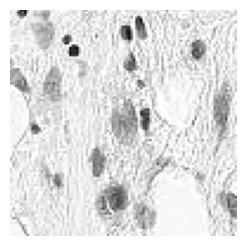

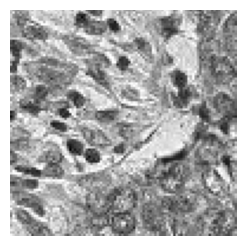

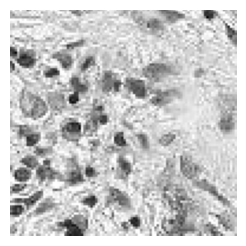

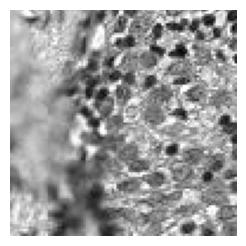

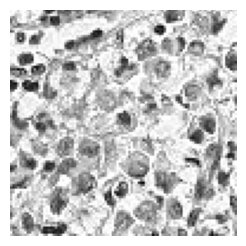

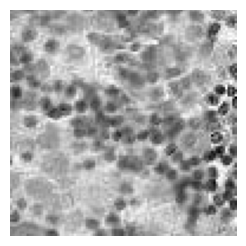

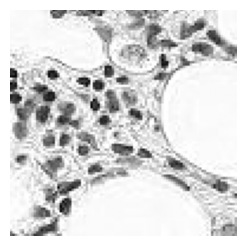

In [8]:
for i,id_ in enumerate(malignantIDs[:nrows*ncols]):
    file_names = os.path.join(path2train, id_ + '.tif')

    # load image
    img = Image.open(file_names)

    # draw 32*32 rectangles
    draw = ImageDraw.Draw(img)
    # draw.rectangle(((32,32), (64,64)), outline='green')
    plt.subplot(nrows,ncols,i+1)
    
    if color == True:
        plt.imshow(np.array(img))
    else:
        plt.imshow(np.array(img)[:,:,0], cmap='gray')
    plt.axis('off')
    plt.show()
    plt.clf()


In [9]:
print("Image shape: ", np.array(img).shape)
print("Image values range from %s to %s", np.array(img).min(), np.array(img).max())

Image shape:  (96, 96, 3)
Image values range from %s to %s 0 255


### Create a Custom Dataset

In [10]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

from PIL import Image
import pandas as pd
import os

torch.manual_seed(42)

In [11]:
class histCancerDataset(Dataset):
    
    def __init__(self, data_dir, transform, data_type='train'):

        super().__init__()

        # path to images
        path2data = os.path.join(data_dir, data_type)

        # get list of images
        filenames = os.listdir(path2data)

        # get full path to images
        self.full_filenames = [os.path.join(path2data,f) for f in filenames]

        # labels from train or test .csv
        csv_filename = data_type + '_labels.csv'
        path2csvLabel = os.path.join(data_dir,csv_filename)
        labels_df = pd.read_csv(path2csvLabel)

        labels_df.set_index("id",inplace=True)

        # obtain labels from dataframe
        self.labels = [labels_df.loc[filename[:-4]].values[0] for filename in filenames]
        
        self.transform =transform

    def __len__(self):
        return len(self.full_filenames)
        
    def __getitem__(self, idx):
        # open image apply transforms and return with label

        image = Image.open(self.full_filenames[idx]) # PIL Image
        image = self.transform(image)

        return image, self.labels[idx]
        


In [12]:
import torchvision.transforms as transforms
data_transformer = transforms.Compose([transforms.ToTensor()])

In [13]:
data_dir = './data/'

histo_dataset = histCancerDataset(data_dir=data_dir,transform=data_transformer, data_type='train')

In [14]:
print(histo_dataset.__len__())


220025


In [15]:
img, label = histo_dataset.__getitem__(idx=5)

print(img.shape, torch.min(img), torch.max(img))

torch.Size([3, 96, 96]) tensor(0.) tensor(1.)


### Splitting the Dataset

In [16]:
len_histo = histo_dataset.__len__()
len_train = 0.8*len_histo
len_val = len_histo-len_train

print(len_train)
print(len_val)

176020.0
44005.0


In [17]:
from torch.utils.data import random_split
train_ds, val_ds = random_split(histo_dataset,[int(len_train),int(len_val)])

In [18]:
for x,y in train_ds:
    print(x.shape)
    print(y)
    break

torch.Size([3, 96, 96])
1


In [19]:
for x,y in val_ds:
    print(x.shape)
    print(y)
    break

torch.Size([3, 96, 96])
0


In [20]:
# Display some images
from torchvision import utils
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

In [21]:
def show(img, label, color=False):
    npimg=img.numpy()
    
    # Change shape C*H*W to H*W*C 
    npimg_transpose = np.transpose(npimg, (1,2,0))

    if color == False:
        npimg_transpose = npimg_transpose[:,:,0]
        plt.imshow(npimg_transpose, interpolation='nearest', cmap='gray')
    else:
        plt.imshow(npimg_transpose, interpolation='nearest')

    plt.title("Label: "+ str(y))
    plt.show()


In [22]:
# Creating sample images in grid
grid_size = 4
random_indice = np.random.randint(0, len(train_ds), grid_size)
print("Randomly selected image indices: ",random_indice)

Randomly selected image indices:  [121958 146867 131932 103694]


In [23]:
x_grid_train = [train_ds[i][0] for i in random_indice]
[print(train_ds[i][1]) for i in random_indice]
y_grid_train = [train_ds[i][1] for i in random_indice]

x_grid_train=utils.make_grid(x_grid_train, nrow=4, padding=2)
print(x_grid_train.shape)

0
0
1
0
torch.Size([3, 100, 394])


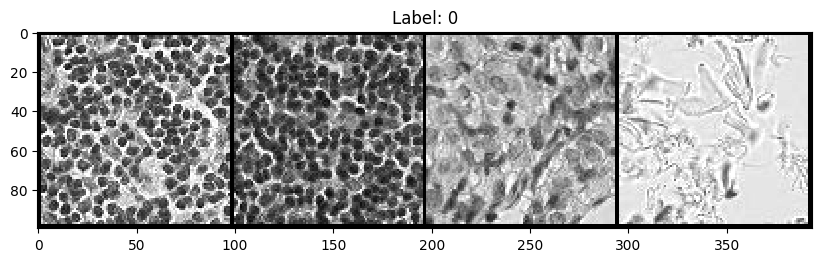

In [24]:
plt.rcParams['figure.figsize'] = (10.0, 5)
show(x_grid_train,y_grid_train)

In [25]:
## This is great usage of grid show of images
def show_grid(images, labels, nrow=4, color=False):
    n_images = len(images)
    ncol = nrow
    nrow = int(np.ceil(n_images / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3*nrow))
    axes = axes.flatten()

    for idx, (img, lbl) in enumerate(zip(images, labels)):
        # convert C×H×W → H×W×C
        npimg = img.numpy().transpose((1,2,0))
        if not color:
            npimg = npimg[:, :, 0]
            axes[idx].imshow(npimg, cmap='gray', interpolation='nearest')
        else:
            axes[idx].imshow(npimg, interpolation='nearest')

        axes[idx].set_title(f"Label: {lbl}")
        axes[idx].axis('off')

    # hide extra axes if any
    for ax in axes[len(images):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


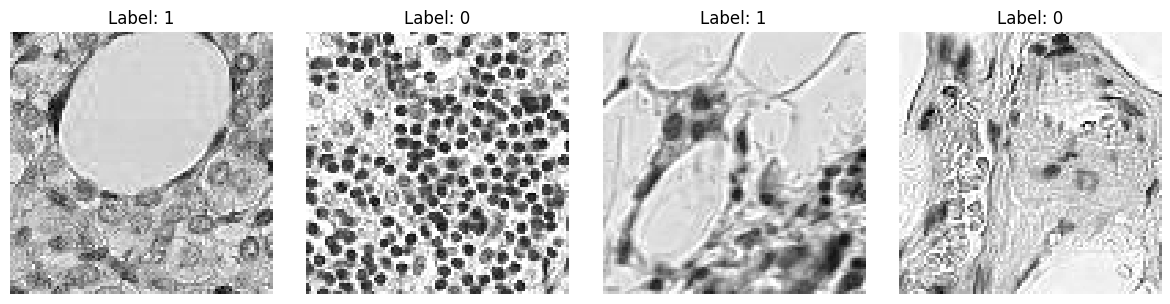

In [26]:
# Train images with label
grid_size = 4
random_indices = np.random.randint(0, len(train_ds), grid_size)

images = [train_ds[i][0] for i in random_indices]
labels = [train_ds[i][1] for i in random_indices]

show_grid(images, labels, nrow=4, color=False)

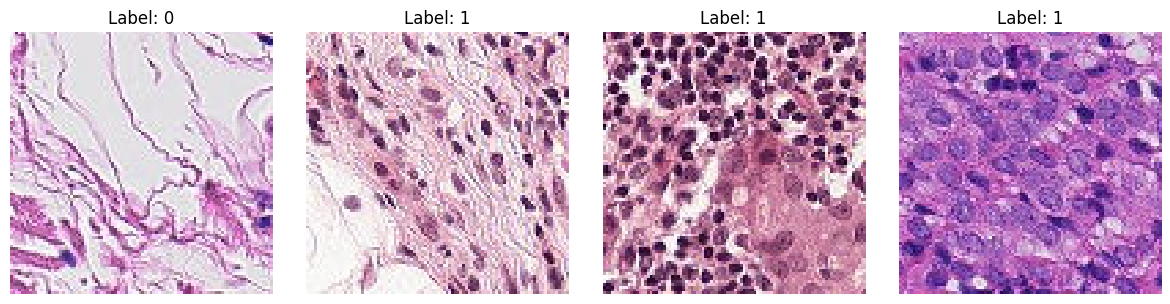

In [27]:
grid_size = 4 
random_indice = np.random.randint(0, len(val_ds), grid_size)

images = [val_ds[i][0] for i in random_indice]
labels = [val_ds[i][1] for i in random_indice]

show_grid(images, labels, nrow=4, color=True)

### Transforming the Data

In [28]:
train_transformer = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.RandomVerticalFlip(p=1),
    transforms.RandomRotation(45),
    transforms.RandomResizedCrop(96, scale=(0.8,1.0), ratio=(1.0,1.0)),
    transforms.ToTensor()
])

In [29]:
# There is no need for augmentation for val_ds
val_transformer = transforms.Compose([transforms.ToTensor()])

In [30]:
# Overwrite the tranform function
train_ds.transform = train_transformer
val_ds.transform = val_transformer

### Create Dataloader

In [31]:
from torch.utils.data import DataLoader

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

# Training batch 
for x,y in train_dl:
    print("Training dataloader: ",x.shape)
    break

# Validation batch 
for x,y in val_dl:
    print("Validation dataloader: ",x.shape)
    break

Training dataloader:  torch.Size([32, 3, 96, 96])
Validation dataloader:  torch.Size([64, 3, 96, 96])


### Building Classification Model

In [32]:
# Dumb baselines
# y_val = [y for _,y in val_ds]

# def accuracy(labels, out):
#     return np.sum(out==labels)/float(len(labels))

# Accuracy if all are zero

# acc_all_zero = accuracy(y_val, np.zeros_like(y_val))
# print("Output if all prediction are zero: ", acc_all_zero)

In [33]:
# acc_all_one = accuracy(y_val, np.ones_like(y_val))
# print("Output if all prediction are zero: ", acc_all_one)

#### Cov2d Output Size

For each spatial dimension (height or width), the Conv2d output size is:

$$
\text{OutputSize} =
\left\lfloor
\frac{H_\text{in} + 2P - D \cdot (K - 1) - 1}{S} + 1
\right\rfloor
$$

Where:

| Symbol                  | Meaning                                    |
| ----------------------- | ------------------------------------------ |
| $H_\text{in}$           | Input size (height or width)               |
| $K$                     | Kernel size                                |
| $P$                     | Padding (pixels added around input)        |
| $S$                     | Stride (step size of filter)               |
| $D$                     | Dilation (spacing between kernel elements) |
| $\lfloor \cdot \rfloor$ | Floor (round down to integer)              |


In [34]:
from torch import nn

def findConv2dOutShape(H_in,W_in, conv, pool=2):
    # This function is important to find conv2d shape automaticly.
    # >> Code explanation is above << #
    #get conv arguments
    kernel_size = conv.kernel_size
    stride = conv.stride
    padding = conv.padding
    dilation = conv.dilation

    H_out = np.floor((H_in+2*padding[0]-dilation[0]*(kernel_size[0]-1)-1)/stride[0]+1)
    W_out = np.floor((W_in+2*padding[1]-dilation[1]*(kernel_size[1]-1)-1)/stride[1]+1)

    if pool:
        H_out=H_out/pool
        W_out=W_out/pool
    
    return int(H_out), int(W_out)

In [35]:
conv_example = nn.Conv2d(3,8,kernel_size=3)
h,w = findConv2dOutShape(96,96,conv=conv_example)
print(h,w)

47 47


#### Define Model

In [36]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, params):
        super(Net,self).__init__()

        C_in,H_in,W_in = params["input_shape"]
        initial_filters = params["initial_filters"]
        num_fc1 = params["num_fc1"]
        num_classes = params["num_classes"]
        self.droupout_rate = params["dropout_rate"]

        self.conv1 = nn.Conv2d(C_in, initial_filters, kernel_size=3)
        h,w = findConv2dOutShape(H_in=H_in,W_in=W_in,conv=self.conv1)

        self.conv2 = nn.Conv2d(initial_filters, 2*initial_filters, kernel_size=3)
        h,w = findConv2dOutShape(H_in=h,W_in=w,conv=self.conv2)

        self.conv3 = nn.Conv2d(2*initial_filters, 4*initial_filters, kernel_size=3)
        h,w = findConv2dOutShape(H_in=h,W_in=w,conv=self.conv3)

        self.conv4 = nn.Conv2d(4*initial_filters, 8*initial_filters, kernel_size=3)
        h,w, = findConv2dOutShape(H_in=h,W_in=w,conv=self.conv4)

        self.num_flatten = h*w*8*initial_filters

        self.fc1 = nn.Linear(self.num_flatten, num_fc1)
        self.fc2 = nn.Linear(num_fc1, num_classes)

    def forward(self, x):
        x=F.relu(self.conv1(x))
        x=F.max_pool2d(x,2,2)

        x=F.relu(self.conv2(x))
        x=F.max_pool2d(x,2,2)

        x=F.relu(self.conv3(x))
        x=F.max_pool2d(x,2,2)

        x=F.relu(self.conv4(x))
        x=F.max_pool2d(x,2,2)

        x=x.view(-1,self.num_flatten)

        x=F.relu(self.fc1(x))
        x=F.dropout(x,self.droupout_rate)

        x=self.fc2(x)
        return F.log_softmax(x,dim=1)

In [37]:
# Model parameters dictinary
param_model={
    "input_shape": (3,96,96),
    "initial_filters": 8,
    "num_fc1": 100,
    "dropout_rate": 0.25,
    "num_classes": 2
}

# Create a model
cnn_model = Net(param_model)

In [38]:
if torch.cuda.is_available():
    device=torch.device("cuda:0")
    cnn_model=cnn_model.to(device=device)

In [39]:
print(cnn_model)

Net(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)


In [40]:
print(next(cnn_model.parameters()).device)

cuda:0


#### Model Summary and Visualization

In [41]:
from torchsummary import summary
summary(cnn_model, input_size=(3,96,96))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 94, 94]             224
            Conv2d-2           [-1, 16, 45, 45]           1,168
            Conv2d-3           [-1, 32, 20, 20]           4,640
            Conv2d-4             [-1, 64, 8, 8]          18,496
            Linear-5                  [-1, 100]         102,500
            Linear-6                    [-1, 2]             202
Total params: 127,230
Trainable params: 127,230
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.11
Forward/backward pass size (MB): 0.92
Params size (MB): 0.49
Estimated Total Size (MB): 1.51
----------------------------------------------------------------


In [42]:
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 127230


In [43]:
# Total trainable parameters
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")


Trainable parameters: 127230


In [52]:
from torchviz import make_dot

# Choose device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model.to(device)

# Dummy input on same device
dummy_input = torch.randn(1, *param_model["input_shape"]).to(device)

# Forward pass
output = cnn_model(dummy_input)

make_dot(output, params=dict(list(cnn_model.named_parameters()))).render("./model/cnn_model", format="pdf")

'model\\cnn_model.pdf'

In [53]:
torch.save(cnn_model, "./model/cnn_model_full.pth")

In [54]:
import netron as nt

nt.start("./model/cnn_model_full.pth")

Serving './model/cnn_model_full.pth' at http://localhost:8080


('localhost', 8080)

In [55]:
nt.stop()

Stopping http://localhost:8080


### Loss Function

In [64]:
loss_func = nn.NLLLoss(reduce="sum")

torch.manual_seed(42)

n,c = 8,2

y = torch.randn(n,c,requires_grad=True)
ls_F = nn.LogSoftmax(dim=1)
y_out = ls_F(y)
print(y_out.shape)

target = torch.randint(c,size=(n,))
print(target.shape)

loss = loss_func(y_out,target)
print(loss.item())


torch.Size([8, 2])
torch.Size([8])
0.9297347664833069


In [65]:
# Compute gradient of loss with respect to y
loss.backward()
print(y.data)

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487],
        [-0.3925, -1.4036],
        [-0.7279, -0.5594],
        [-0.7688,  0.7624]])
